Plot successfully saved to Figure_1d.pdf.


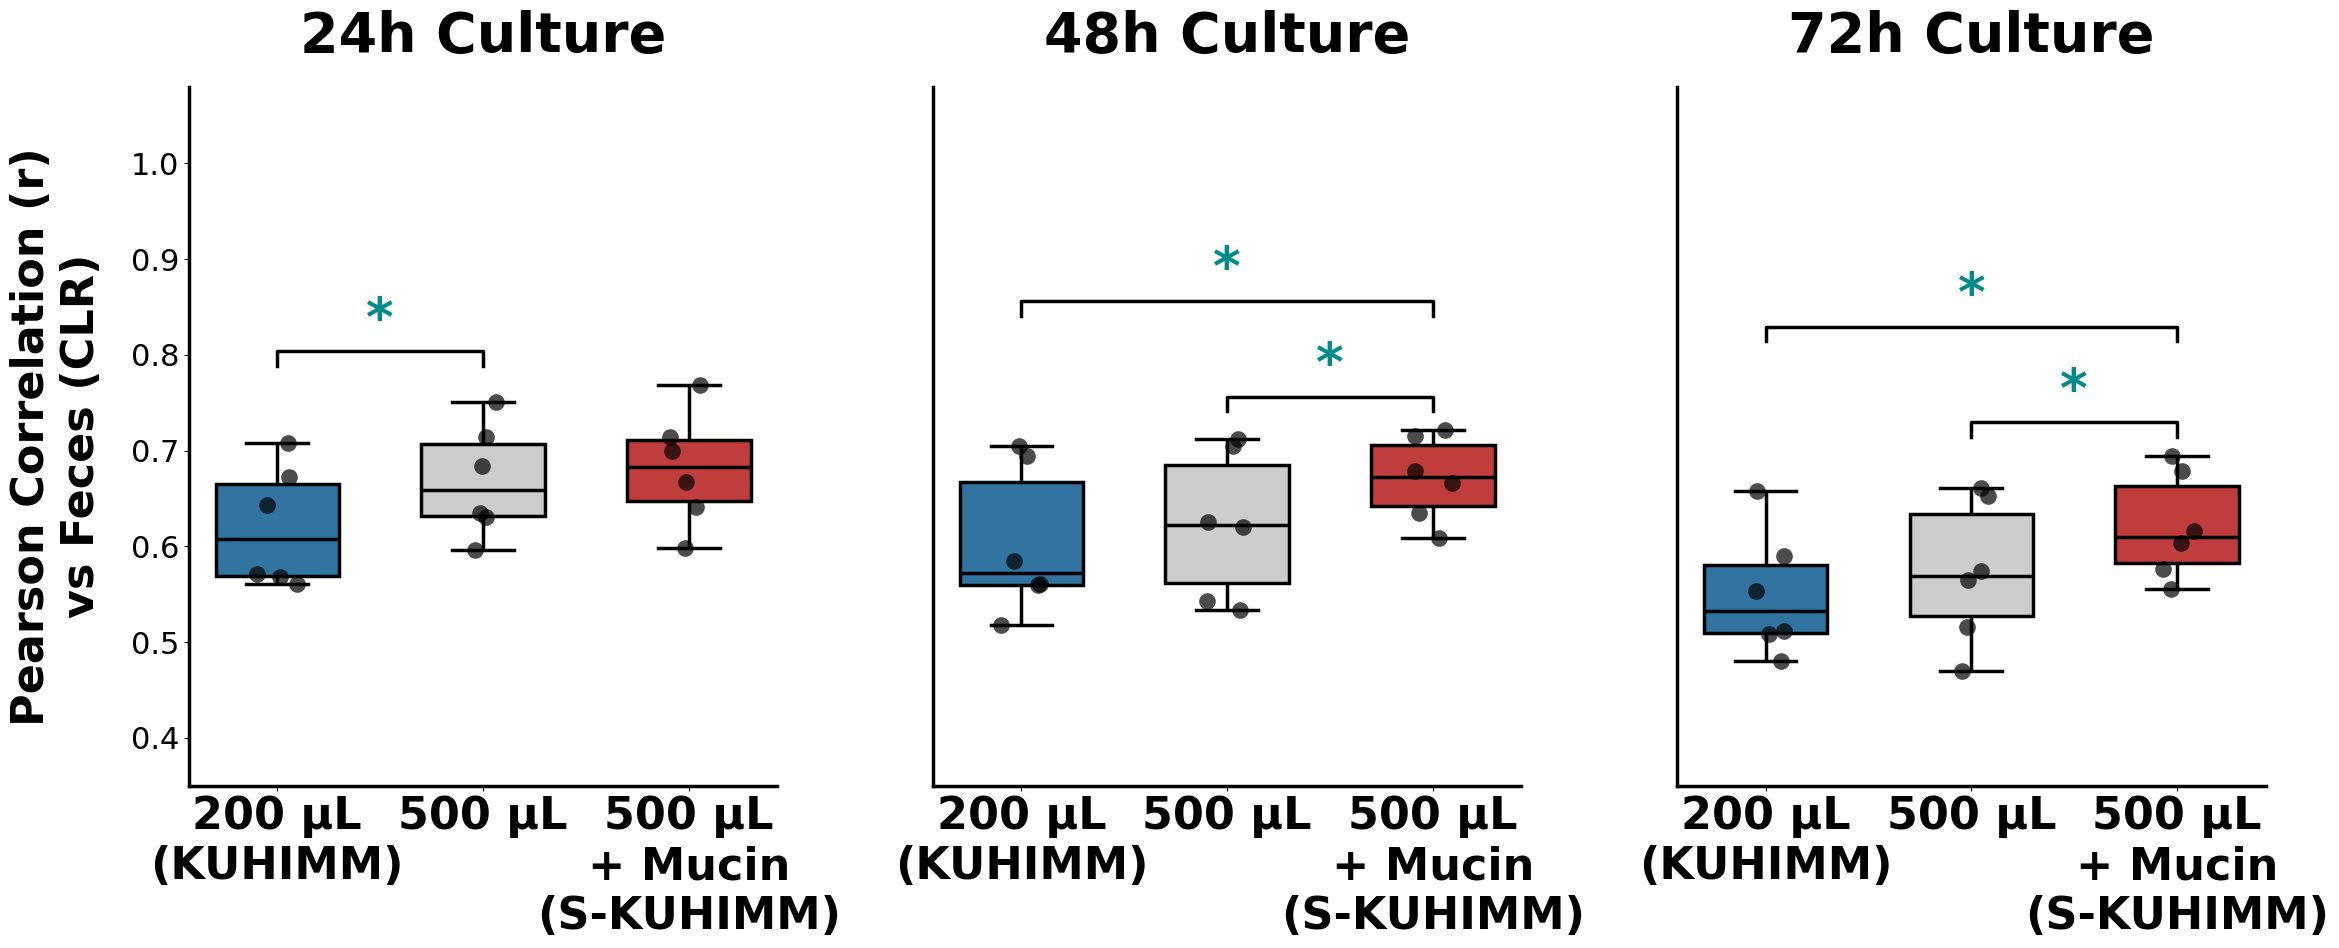

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, wilcoxon
from scipy.stats.mstats import gmean
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'black',  # 'black' represents extra bold for titles
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular',
    'figure.subplot.left': 0.15 # Ensure left margin is large enough
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38          # Optimized for compact fitting

def annotate_p(ax, x1, x2, y, h, p_val):
    """Adds a strict, professional statistical bracket with a turquoise asterisk."""
    if p_val < 0.05:
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, c='k')
        ax.text((x1+x2)*0.5, y+h + 0.005, '*', ha='center', va='bottom',
                color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

# =============================================================================
# 1. Load Data and Classify Conditions
# =============================================================================
df = pd.read_csv('(1d)_500muc_16S_Genus_level.csv')
bac_cols = [c for c in df.columns if c.startswith('d__Bacteria')]

def classify_conditions(c):
    """Classify culture conditions based on sample ID."""
    if 'FEC' in c:
        return 'Baseline', 0
    time = None
    if '24h' in c: time = '24h'
    elif '48h' in c: time = '48h'
    elif '72h' in c: time = '72h'

    if not time:
        return None, None

    is_mucin = any(m in c for m in ['MUC', '0.8gMUC', '08MUC'])
    group = None

    if '200' in c:
        group = 'KUHIMM (200 µL)'
    elif '500' in c:
        group = 'S-KUHIMM (500 µL + Mucin)' if is_mucin else 'KUHIMM (500 µL)'

    return group, time

df['Group'], df['Time'] = zip(*df['Condition'].apply(classify_conditions))
df['Donor'] = df['Condition'].str.extract(r'^(HS-[^-]+|[^0-9-]+)')

# =============================================================================
# 2. Strict CLR-Pearson Stability Calculation
# =============================================================================
def clr_transform(x):
    """Perform Centered Log-Ratio (CLR) transformation with robust pseudocounts."""
    x = np.array(x, dtype=float)
    if (x == 0).any():
        pseudo = x[x > 0].min() * 0.5 if (x > 0).any() else 1e-9
        x = np.where(x == 0, pseudo, x)
    return np.log(x / gmean(x))

results = []
donors = df[df['Group'] == 'Baseline']['Donor'].dropna().unique()
group_order = ['KUHIMM (200 µL)', 'KUHIMM (500 µL)', 'S-KUHIMM (500 µL + Mucin)']

for d in donors:
    fec_rows = df[(df['Donor'] == d) & (df['Group'] == 'Baseline')]
    if len(fec_rows) == 0:
        continue

    fec_vals = fec_rows[bac_cols].values[0].astype(float)

    for t in ['24h', '48h', '72h']:
        for g in group_order:
            target = df[(df['Donor'] == d) & (df['Group'] == g) & (df['Time'] == t)]
            if len(target) > 0:
                for _, row in target.iterrows():
                    vals = row[bac_cols].values.astype(float)

                    mask = (fec_vals > 0) | (vals > 0)
                    if mask.sum() > 3:
                        r, _ = pearsonr(clr_transform(fec_vals[mask]), clr_transform(vals[mask]))
                        results.append({'Donor': d, 'Time': t, 'Group': g, 'Pearson_CLR': r})

df_res = pd.DataFrame(results)
df_agg = df_res.groupby(['Donor', 'Time', 'Group'])['Pearson_CLR'].mean().reset_index()

# =============================================================================
# 3. Plotting Configuration
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

palette_box = {
    'KUHIMM (200 µL)': '#1f77b4',
    'KUHIMM (500 µL)': '#CCCCCC',
    'S-KUHIMM (500 µL + Mucin)': '#d62728'
}

display_labels = ['200 µL\n(KUHIMM)', '500 µL', '500 µL\n+ Mucin\n(S-KUHIMM)']

for idx, t in enumerate(['24h', '48h', '72h']):
    ax = axes[idx]
    df_t = df_agg[df_agg['Time'] == t]

    sns.boxplot(
        x='Group', y='Pearson_CLR', data=df_t, order=group_order,
        palette=palette_box, width=0.6, ax=ax, showfliers=False, linewidth=2.5,
        boxprops=dict(alpha=1.0)
    )

    for patch in ax.patches: patch.set_edgecolor('black')
    for line in ax.lines: line.set_color('black')

    sns.stripplot(
        x='Group', y='Pearson_CLR', data=df_t, order=group_order,
        color='black', alpha=0.7, size=12, jitter=True, ax=ax
    )

    ax.set_title(f"{t} Culture", fontsize=40, fontweight='black', pad=25)
    ax.set_xlabel("")
    ax.set_xticks(range(len(display_labels)))
    ax.set_xticklabels(display_labels, rotation=0, fontsize=32, fontweight='bold')

    if idx == 0:
        ax.set_ylabel("Pearson Correlation (r)\nvs Feces (CLR)", fontsize=32, fontweight='bold', labelpad=20)
    else:
        ax.set_ylabel("")
        for tick in ax.yaxis.get_major_ticks():
            tick.tick1line.set_visible(False)

    # ** FIX: Internal ceiling strictly set to 1.08 to safely fit the higher bracket **
    # The visual ticks will still end at 1.0 to prevent excessive empty space
    yticks = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    ax.set_ylim(0.35, 1.08)
    ax.set_yticks(yticks)

    # Matching font rules (Normal weight, size 22)
    labels_y = ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=22)
    for label in labels_y:
        label.set_fontweight('normal')

    # =========================================================================
    # 4. Statistical Testing (Significantly Raised Tier 2 Bracket)
    # =========================================================================
    s_muc = df_t[df_t['Group'] == 'S-KUHIMM (500 µL + Mucin)'].sort_values('Donor')['Pearson_CLR'].values
    k_500 = df_t[df_t['Group'] == 'KUHIMM (500 µL)'].sort_values('Donor')['Pearson_CLR'].values
    k_200 = df_t[df_t['Group'] == 'KUHIMM (200 µL)'].sort_values('Donor')['Pearson_CLR'].values

    # Determine maximum value for the current timepoint
    max_y_t = df_t['Pearson_CLR'].max()

    # Tier 1 (Lower): For adjacent comparisons (0 vs 1, 1 vs 2)
    y_tier1 = max_y_t + 0.02
    # ** FIX: Tier 2 (Higher): For spanning comparison (0 vs 2) -> Raised much higher **
    y_tier2 = max_y_t + 0.12

    bracket_height = 0.015

    if len(k_200) == len(k_500) and len(k_500) == len(s_muc) and len(k_200) > 0:
        _, p_200_500 = wilcoxon(k_200, k_500)
        _, p_500_muc = wilcoxon(k_500, s_muc)
        _, p_200_muc = wilcoxon(k_200, s_muc)

        # Draw adjacent brackets on the SAME lower level (Tier 1)
        if p_200_500 < 0.05:
            annotate_p(ax, 0, 1, y_tier1, bracket_height, p_200_500)
        if p_500_muc < 0.05:
            annotate_p(ax, 1, 2, y_tier1, bracket_height, p_500_muc)

        # Draw spanning bracket strictly on the HIGHER level (Tier 2) to avoid all overlap
        if p_200_muc < 0.05:
            # Force it to the higher tier always to maintain a clean layout
            annotate_p(ax, 0, 2, y_tier2, bracket_height, p_200_muc)

sns.despine()
plt.tight_layout()

# Export High-Resolution PDF
output_file = "Figure_1d.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")